Libraries and classes import

In [19]:
import sys
import subprocess
import importlib.util

def _ensure_packages(packages):
    missing = [pkg for pkg in packages if importlib.util.find_spec(pkg) is None]
    if missing:
        print('Installing missing packages:', missing)
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', *missing])
        for pkg in missing:
            importlib.import_module(pkg)

_ensure_packages(['numpy', 'pandas', 'matplotlib', 'openpyxl', 'scipy'])

import csv
from pathlib import Path

import numpy as np
np.float_ = np.float64
import scipy as sp

import pandas as pd
import matplotlib.pyplot as pp
import openpyxl
from IPython.display import display, Markdown
from matplotlib.lines import Line2D

%matplotlib inline

Filtering

In [20]:
headers = []
noofrows = 0
noofcols = 0
data = []
result = []
listofcontents = []
info = []
with open('info.csv') as csvfile:
    readCSV = csv.reader(csvfile, delimiter=',')
    for line in readCSV:
        info.append(line)
df = pd.read_excel('%s.xlsx' % info[0][2], sheet_name=0, header=None, dtype=str)
for line in df.fillna('').astype(str).values.tolist():
    data.append(line)
    noofrows = noofrows + 1
    #extracting headers from data
noofcols = len(data[0])
magnesium, aluminum, silicon, sulfur = [0]*noofrows, [0]*noofrows, [0]*noofrows, [0]*noofrows
calcium, manganese, iron, zirconium = [0]*noofrows, [0]*noofrows, [0]*noofrows, [0]*noofrows
titanium = [0]*noofrows
partno, x_abs, y_abs, dave = [0]*noofrows, [0]*noofrows, [0]*noofrows, [0]*noofrows
aspect, area, counts, oxygen = [0]*noofrows, [0]*noofrows, [0]*noofrows, [0]*noofrows
Mg_v, Al_v, Si_v, S_v = [], [], [], []
Ca_v, Mn_v, Fe_v, Zr_v = [], [], [], []
Ti_v = []
partno_v, x_abs_v, y_abs_v, dave_v = [], [], [], []
aspect_v, area_v, counts_v, O_v = [], [], [], []
for i in range(noofcols):
    if data[0][i] == 'Feature':
        for j in range(2,noofrows):
            result = data[j][i]
            partno[j] = result
    if data[0][i] == 'Stage X (mm)':
        for j in range(2,noofrows):
            result = data[j][i]
            x_abs[j] = result
    if data[0][i] == 'Stage Y (mm)':
        for j in range(2,noofrows):
            result = data[j][i]
            y_abs[j] = result
    if data[0][i] == 'ECD (µm)':
        for j in range(2,noofrows):
            result = data[j][i]
            dave[j] = result
    if data[0][i] == 'Aspect Ratio':
        for j in range(2,noofrows):
            result = data[j][i]
            aspect.append(result)
    if data[0][i] == 'Area (sq. µm)':
        for j in range(2,noofrows):
            result = data[j][i]
            area[j] = result
    if data[0][i] == 'Spectrum':
        for j in range(2,noofrows):
            result = data[j][i]
            counts[j] = result
    if data[0][i] == 'O (Wt%)':
        for j in range(2,noofrows):
            result = data[j][i]
            oxygen[j] = result
    if data[0][i] == 'Mg (Wt%)':
        for j in range(2,noofrows):
            result = data[j][i]
            magnesium[j] = result
    if data[0][i] == 'Al (Wt%)':
        for j in range(2,noofrows):
            result = data[j][i]
            aluminum[j] = result
    if data[0][i] == 'Si (Wt%)':
        for j in range(2,noofrows):
            result = data[j][i]
            silicon[j] = result
    if data[0][i] == 'S (Wt%)':
        for j in range(2,noofrows):
            result = data[j][i]
            sulfur[j] = result
    if data[0][i] == 'Ca (Wt%)':
        for j in range(2,noofrows):
            result = data[j][i]
            calcium[j] = result
    if data[0][i] == 'Mn (Wt%)':
        for j in range(2,noofrows):
            result = data[j][i]
            manganese[j] = result
    if data[0][i] == 'Fe (Wt%)':
        for j in range(2,noofrows):
            result = data[j][i]
            iron[j] = result
    if data[0][i] == 'Zr (Wt%)':
        for j in range(2,noofrows):
            result = data[j][i]
            zirconium[j] = result
    if data[0][i] == 'Ti (Wt%)':
        for j in range(2,noofrows):
            result = data[j][i]
            titanium[j] = result
#creating filter
j = 1
for i in range (2, noofrows):
    #Set filter here:
    #if True:
    if (float(titanium[i]) >= float(5) and float(iron[i]) <= float(50)):
        partno_v.append(partno[i]), x_abs_v.append(x_abs[i]), y_abs_v.append(y_abs[i]), dave_v.append(dave[i])
        aspect_v.append(aspect[i]), area_v.append(area[i]), counts_v.append(counts[i]), O_v.append(oxygen[i])
        Mg_v.append(magnesium[i]), Al_v.append(aluminum[i]), Si_v.append(silicon[i]), S_v.append(sulfur[i])
        Ca_v.append(calcium[i]), Mn_v.append(manganese[i]), Fe_v.append(iron[i]), Zr_v.append(zirconium[i])
        Ti_v.append(titanium[i])


list(np.float_(O_v));
list(np.float_(Mg_v));
list(np.float_(Al_v));
list(np.float_(Si_v));
list(np.float_(S_v));
list(np.float_(Ca_v));
list(np.float_(Mn_v));
list(np.float_(Fe_v));
list(np.float_(Zr_v));
print(len(Al_v))

1059


In [21]:
# Clustering Algorithm
# Set the distance threshold here (in µm)
DISTANCE_THRESHOLD = 40.21

def cluster_features(x_coords, y_coords, ecd_values, distance_threshold=5.0):
    
    n_features = len(x_coords)
    
    # Convert coordinates from mm to µm for consistent units
    x = np.array([float(x) * 1000 if x != 0 else 0 for x in x_coords])
    y = np.array([float(y) * 1000 if y != 0 else 0 for y in y_coords])
    ecd = np.array([float(d) if d != 0 else 0 for d in ecd_values])
    
    cluster_ids = [-1] * n_features  # -1 = unassigned
    current_cluster = 1
    
    for start_feature in range(n_features):
        if cluster_ids[start_feature] != -1 or ecd[start_feature] == 0:
            continue  # Already assigned or invalid
        
        # Start new cluster
        cluster_members = set([start_feature])
        to_check = [start_feature]
        
        # Grow cluster by finding neighbors
        while to_check:
            current = to_check.pop(0)
            cluster_ids[current] = current_cluster
            
            # Get the boundary of the current cluster
            # Check all unassigned features against all cluster members
            for candidate in range(n_features):
                if cluster_ids[candidate] != -1 or ecd[candidate] == 0:
                    continue  # Already assigned or invalid
                
                # Calculate minimum edge-to-edge distance from candidate to any cluster member
                min_edge_distance = float('inf')
                
                for cluster_member in cluster_members:
                    # Center-to-center distance
                    dx = x[candidate] - x[cluster_member]
                    dy = y[candidate] - y[cluster_member]
                    center_distance = np.sqrt(dx**2 + dy**2)
                    
                    # Edge-to-edge distance (subtract radii)
                    radius_candidate = ecd[candidate] / 2
                    radius_member = ecd[cluster_member] / 2
                    edge_distance = center_distance - radius_candidate - radius_member
                    
                    min_edge_distance = min(min_edge_distance, edge_distance)
                
                # If within threshold, add to cluster
                if min_edge_distance <= distance_threshold:
                    if candidate not in cluster_members:
                        cluster_members.add(candidate)
                        to_check.append(candidate)
        
        current_cluster += 1
    
    return cluster_ids, ecd, x, y

valid_features = []

# Use the filtered arrays (partno_v, x_abs_v, y_abs_v, dave_v)
for idx in range(len(partno_v)):
    if partno_v[idx] and x_abs_v[idx] and y_abs_v[idx] and dave_v[idx]:
        valid_features.append({
            'feature': partno_v[idx],
            'x': float(x_abs_v[idx]),
            'y': float(y_abs_v[idx]),
            'ecd': float(dave_v[idx]),
            'index': idx,
            'Ti': float(Ti_v[idx]),
            'Fe': float(Fe_v[idx]),
            'O': float(O_v[idx]),
            'Mg': float(Mg_v[idx]),
            'Al': float(Al_v[idx]),
            'Si': float(Si_v[idx]),
            'S': float(S_v[idx]),
            'Ca': float(Ca_v[idx]),
            'Mn': float(Mn_v[idx]),
            'Zr': float(Zr_v[idx])
        })

print(f"Processing {len(valid_features)} filtered features...")

# Extract arrays for clustering
x_coords = [f['x'] for f in valid_features]
y_coords = [f['y'] for f in valid_features]
ecd_vals = [f['ecd'] for f in valid_features]

# Run clustering algorithm
cluster_ids, ecd_µm, x_µm, y_µm = cluster_features(x_coords, y_coords, ecd_vals, distance_threshold=DISTANCE_THRESHOLD)

# Calculate max distance (diameter) for each cluster
from scipy.spatial import ConvexHull

max_distances = {}
for cluster_id in set(cluster_ids):
    # Get all features in this cluster
    cluster_indices = [i for i, c in enumerate(cluster_ids) if c == cluster_id]
    
    if len(cluster_indices) == 1:
        max_distances[cluster_id] = ecd_µm[cluster_indices[0]]  # Single feature diameter
    else:
        # Get coordinates in µm for this cluster
        cluster_points = np.array([[x_µm[i], y_µm[i]] for i in cluster_indices])
        
        if len(cluster_indices) >= 3:
            try:
                # Use convex hull to find diameter
                hull = ConvexHull(cluster_points)
                hull_points = cluster_points[hull.vertices]
                hull_indices = [cluster_indices[i] for i in hull.vertices]
                
                # Find maximum distance between any two hull points, including radii
                max_dist = 0
                for i in range(len(hull_points)):
                    for j in range(i+1, len(hull_points)):
                        dist = np.sqrt((hull_points[i][0] - hull_points[j][0])**2 + 
                                     (hull_points[i][1] - hull_points[j][1])**2)
                        total_length = dist + ecd_µm[hull_indices[i]] / 2 + ecd_µm[hull_indices[j]] / 2
                        max_dist = max(max_dist, total_length)
                max_distances[cluster_id] = max_dist
            except:
                # If convex hull fails, check all pairs
                max_dist = 0
                for i in range(len(cluster_points)):
                    for j in range(i+1, len(cluster_points)):
                        dist = np.sqrt((cluster_points[i][0] - cluster_points[j][0])**2 + 
                                     (cluster_points[i][1] - cluster_points[j][1])**2)
                        total_length = dist + ecd_µm[cluster_indices[i]] / 2 + ecd_µm[cluster_indices[j]] / 2
                        max_dist = max(max_dist, total_length)
                max_distances[cluster_id] = max_dist
        else:
            # For 2 features, just calculate distance
            dist = np.sqrt((cluster_points[0][0] - cluster_points[1][0])**2 + 
                         (cluster_points[0][1] - cluster_points[1][1])**2)
            max_distances[cluster_id] = dist + ecd_µm[cluster_indices[0]] / 2 + ecd_µm[cluster_indices[1]] / 2

# Create results dataframe with composition data
cluster_results = pd.DataFrame({
    'Feature ID': [f['feature'] for f in valid_features],
    'X (mm)': x_coords,
    'Y (mm)': y_coords,
    'Cluster': cluster_ids,
    'Max Length (µm)': [max_distances[c] for c in cluster_ids],
    'Ti (Wt%)': [f['Ti'] for f in valid_features],
    'Fe (Wt%)': [f['Fe'] for f in valid_features],
    'O (Wt%)': [f['O'] for f in valid_features],
    'Mg (Wt%)': [f['Mg'] for f in valid_features],
    'Al (Wt%)': [f['Al'] for f in valid_features],
    'Si (Wt%)': [f['Si'] for f in valid_features],
    'S (Wt%)': [f['S'] for f in valid_features],
    'Ca (Wt%)': [f['Ca'] for f in valid_features],
    'Mn (Wt%)': [f['Mn'] for f in valid_features],
    'Zr (Wt%)': [f['Zr'] for f in valid_features]
})

print(f"\nClustering complete!")
print(f"Found {len(set(cluster_ids))} clusters\n")
print(cluster_results.to_string())

Processing 1059 filtered features...

Clustering complete!
Found 541 clusters

     Feature ID    X (mm)    Y (mm)  Cluster  Max Length (µm)   Ti (Wt%)   Fe (Wt%)   O (Wt%)  Mg (Wt%)  Al (Wt%)  Si (Wt%)   S (Wt%)  Ca (Wt%)  Mn (Wt%)  Zr (Wt%)
0          3054 -4.793827 -3.198464        1       316.444935   8.237503  38.347074  5.258630  0.000000  0.020497  0.000000  0.000000  0.000000  0.000000       0.0
1          3055 -4.873730 -3.188521        2         7.717594  10.434662  41.415915  0.000000  0.000000  0.017662  0.648938  0.000000  0.000000  0.000000       0.0
2          3056 -4.774062 -3.158919        1       316.444935   7.432619  49.012473  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000       0.0
3          3057 -4.778423 -3.151336        1       316.444935  12.874953  35.626784  0.000000  0.000000  0.071816  0.000000  0.000000  0.000000  0.000000       0.0
4          3059 -4.674489 -3.144427        1       316.444935  23.402339  35.767195  3.748989  0.0000

Cluster size distribution

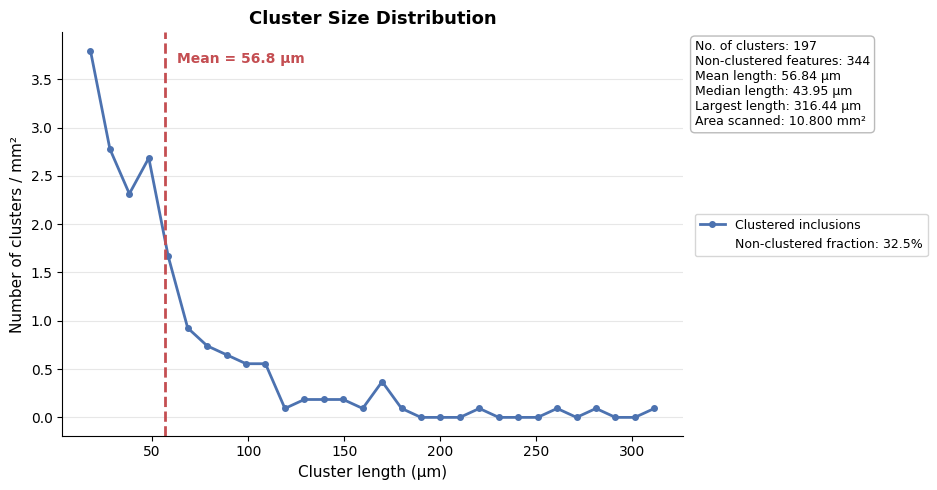

No. of clusters (excluding single-feature clusters): 197
Non-clustered features: 344
Mean cluster length: 56.84 µm
Median cluster length: 43.95 µm
Largest cluster length: 316.44 µm
Non-clustered inclusion fraction: 32.48%
Area scanned: 10.800 mm²


In [22]:
# Cluster size distribution (max length per cluster, in µm)
# Exclude single-feature clusters (non-clustered inclusions) from the distribution

# --- Axis scale control ---
# AUTO_SCALE = True  -> axes scale automatically to the data (default behavior).
# AUTO_SCALE = False -> axes are forced to the fixed X_SCALE / Y_SCALE ranges below,
#                        so plots from different samples can be compared on the same scale.
AUTO_SCALE = True
X_SCALE = (0, 200)   # (min, max) cluster length in µm, used only when AUTO_SCALE is False
Y_SCALE = (0, 3.5)      # (min, max) clusters per mm², used only when AUTO_SCALE is False

cluster_feature_counts = cluster_results.groupby('Cluster').size()
single_feature_clusters = cluster_feature_counts[cluster_feature_counts == 1].index
multi_feature_clusters = cluster_feature_counts[cluster_feature_counts > 1].index

non_clustered_count = cluster_feature_counts.loc[single_feature_clusters].sum()
non_clustered_fraction = non_clustered_count / cluster_feature_counts.sum()

cluster_lengths = cluster_results[cluster_results['Cluster'].isin(multi_feature_clusters)].groupby('Cluster')['Max Length (µm)'].first()
mean_length = cluster_lengths.mean()

# Actual scanned area, as recorded by the instrument (info.csv: "Area analyzed", mm^2)
area_scanned_mm2 = float(info[0][6])

line_color = '#4C72B0'
mean_color = '#C44E52'

pp.rcParams['font.family'] = 'sans-serif'
fig, ax = pp.subplots(figsize=(9.5, 5))

# Bin the cluster lengths, then convert counts to density (clusters per mm²)
# When a fixed X_SCALE is in use, bin over that same range so histograms line up across samples.
if AUTO_SCALE:
    counts, bin_edges = np.histogram(cluster_lengths, bins=30)
else:
    counts, bin_edges = np.histogram(cluster_lengths, bins=30, range=X_SCALE)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
density = counts / area_scanned_mm2

ax.plot(bin_centers, density, color=line_color, linewidth=2, marker='o', markersize=4,
        label='Clustered inclusions')

ax.axvline(mean_length, color=mean_color, linewidth=2, linestyle='--')
ax.text(mean_length + cluster_lengths.max() * 0.02, ax.get_ylim()[1] * 0.95,
        f'Mean = {mean_length:.1f} µm',
        color=mean_color, fontsize=10, fontweight='bold', va='top', ha='left')

summary_text = (
    f'No. of clusters: {len(cluster_lengths)}\n'
    f'Non-clustered features: {non_clustered_count}\n'
    f'Mean length: {mean_length:.2f} µm\n'
    f'Median length: {cluster_lengths.median():.2f} µm\n'
    f'Largest length: {cluster_lengths.max():.2f} µm\n'
    f'Area scanned: {area_scanned_mm2:.3f} mm²'
)

ax.text(1.02, 0.98, summary_text,
        transform=ax.transAxes,
        ha='left', va='top',
        fontsize=9,
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white', alpha=0.9, edgecolor='0.7'))

# Add non-clustered (single-feature) fraction as a legend-only entry
ax.plot([], [], ' ', label=f'Non-clustered fraction: {non_clustered_fraction:.1%}')
ax.legend(fontsize=9, loc='upper left', bbox_to_anchor=(1.02, 0.55), borderaxespad=0)

ax.set_xlabel('Cluster length (µm)', fontsize=11)
ax.set_ylabel('Number of clusters / mm²', fontsize=11)
ax.set_title('Cluster Size Distribution', fontsize=13, fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)

# Apply fixed axis scale if requested (after all auto-placed elements like the mean label)
if not AUTO_SCALE:
    ax.set_xlim(X_SCALE)
    ax.set_ylim(Y_SCALE)

pp.tight_layout()
fig.savefig('cluster_size_distribution.png', dpi=150, bbox_inches='tight')
pp.show()

print(f"No. of clusters (excluding single-feature clusters): {len(cluster_lengths)}")
print(f"Non-clustered features: {non_clustered_count}")
print(f"Mean cluster length: {mean_length:.2f} µm")
print(f"Median cluster length: {cluster_lengths.median():.2f} µm")
print(f"Largest cluster length: {cluster_lengths.max():.2f} µm")
print(f"Non-clustered inclusion fraction: {non_clustered_fraction:.2%}")
print(f"Area scanned: {area_scanned_mm2:.3f} mm²")

Largest cluster plot

Largest cluster: Cluster 1 with 24 features and max length 316.4µm
Plot saved as: largest_cluster.png


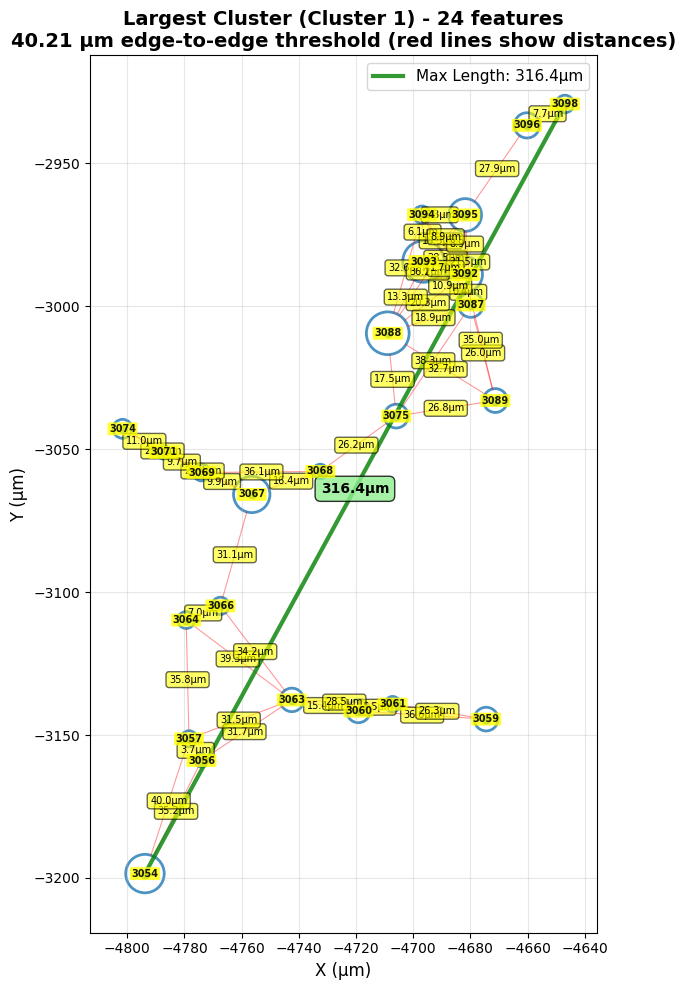

Visualization complete!


In [23]:
# Find the largest cluster (by max length)
largest_cluster = max(max_distances, key=max_distances.get)
largest_cluster_size = len([c for c in cluster_ids if c == largest_cluster])
largest_cluster_max_length = max_distances[largest_cluster]

print(f"Largest cluster: Cluster {largest_cluster} with {largest_cluster_size} features and max length {largest_cluster_max_length:.1f}µm")

fig, ax = pp.subplots(figsize=(14, 10))

# Plot only the largest cluster
cluster_color = pp.cm.tab20(0)

# Get all features in the largest cluster
cluster_features_indices = []
for idx, (x, y, ecd, cid) in enumerate(zip(x_µm, y_µm, ecd_µm, cluster_ids)):
    if ecd > 0 and cid == largest_cluster:
        cluster_features_indices.append(idx)

# Find the two farthest features in the cluster (by total inclusion size)
max_farthest_dist = 0
farthest_pair = None
for i, idx1 in enumerate(cluster_features_indices):
    for idx2 in cluster_features_indices[i+1:]:
        x1, y1 = x_µm[idx1], y_µm[idx1]
        x2, y2 = x_µm[idx2], y_µm[idx2]
        
        dx = x2 - x1
        dy = y2 - y1
        dist = np.sqrt(dx**2 + dy**2)
        
        # Add both feature radii
        total_length = dist + ecd_µm[idx1] / 2 + ecd_µm[idx2] / 2
        
        if total_length > max_farthest_dist:
            max_farthest_dist = total_length
            farthest_pair = (idx1, idx2, x1, y1, x2, y2, total_length)

# Draw edge-to-edge distance lines between features that are neighbors (within threshold)
for i, idx1 in enumerate(cluster_features_indices):
    for idx2 in cluster_features_indices[i+1:]:
        x1, y1, ecd1 = x_µm[idx1], y_µm[idx1], ecd_µm[idx1]
        x2, y2, ecd2 = x_µm[idx2], y_µm[idx2], ecd_µm[idx2]
        
        r1 = ecd1 / 2
        r2 = ecd2 / 2
        
        # Calculate direction from feature 1 to feature 2
        dx = x2 - x1
        dy = y2 - y1
        dist_centers = np.sqrt(dx**2 + dy**2)
        
        if dist_centers > 0:
            # Calculate edge-to-edge distance
            edge_distance = dist_centers - r1 - r2
            
            # Only draw line if features are neighbors (within threshold)
            if edge_distance <= DISTANCE_THRESHOLD:
                # Normalize direction
                ux = dx / dist_centers
                uy = dy / dist_centers
                
                # Start point on edge of circle 1
                edge_x1 = x1 + r1 * ux
                edge_y1 = y1 + r1 * uy
                
                # End point on edge of circle 2
                edge_x2 = x2 - r2 * ux
                edge_y2 = y2 - r2 * uy
                
                # Draw line between edges
                ax.plot([edge_x1, edge_x2], [edge_y1, edge_y2], 'r-', linewidth=0.8, alpha=0.4)
                
                # Add distance text at midpoint of line
                mid_x = (edge_x1 + edge_x2) / 2
                mid_y = (edge_y1 + edge_y2) / 2
                ax.text(mid_x, mid_y, f'{edge_distance:.1f}µm', fontsize=7, 
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.6),
                       ha='center', va='center')

# Draw green line connecting the two farthest features
if farthest_pair:
    idx1, idx2, x1, y1, x2, y2, total_length = farthest_pair
    ax.plot([x1, x2], [y1, y2], 'g-', linewidth=3, alpha=0.8, label=f'Max Length: {total_length:.1f}µm')
    
    # Add distance text at midpoint
    mid_x = (x1 + x2) / 2
    mid_y = (y1 + y2) / 2
    ax.text(mid_x, mid_y, f'{total_length:.1f}µm', fontsize=10, fontweight='bold',
           bbox=dict(boxstyle='round,pad=0.4', facecolor='lightgreen', alpha=0.8),
           ha='center', va='center')

# Draw circles and labels
for idx in cluster_features_indices:
    x, y, ecd = x_µm[idx], y_µm[idx], ecd_µm[idx]
    circle = pp.Circle((x, y), ecd/2, fill=False, edgecolor=cluster_color, 
                      linewidth=2, alpha=0.8)
    ax.add_patch(circle)
    ax.plot(x, y, 'o', color=cluster_color, markersize=6, alpha=0.9)
    
    ax.text(x, y, str(valid_features[idx]['feature']), 
           fontsize=7, ha='center', va='center', fontweight='bold', alpha=0.9,
           color='black',
           bbox=dict(boxstyle='round,pad=0.15', facecolor='yellow', alpha=0.8, edgecolor='none'))

ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_xlabel('X (µm)', fontsize=12)
ax.set_ylabel('Y (µm)', fontsize=12)
ax.set_title(f'Largest Cluster (Cluster {largest_cluster}) - {largest_cluster_size} features\n{DISTANCE_THRESHOLD} µm edge-to-edge threshold (red lines show distances)', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')

pp.tight_layout()
fig.savefig('largest_cluster.png', dpi=150, bbox_inches='tight')
print("Plot saved as: largest_cluster.png")
pp.show()
print("Visualization complete!")

Export

In [24]:
output_file = 'clustering_results.xlsx'
cluster_results.to_excel(output_file, index=False, sheet_name='Clustering Results')
print(f"Results exported to: {output_file}")

summary_file = 'cluster_summary.txt'
with open(summary_file, 'w') as f:
    f.write("SEM Feature Clustering Results\n")
    f.write("="*60 + "\n")
    f.write(f"Distance threshold: 5.0 µm (edge-to-edge)\n")
    f.write(f"Total features processed: {len(valid_features)}\n")
    f.write(f"Total clusters found: {len(set(cluster_ids))}\n\n")
    
    f.write("Cluster Details:\n")
    f.write("-"*60 + "\n")
    for cluster in sorted(set(cluster_ids)):
        features_in_cluster = cluster_results[cluster_results['Cluster'] == cluster]
        f.write(f"Cluster {cluster}: {len(features_in_cluster)} features\n")
        f.write(f"  Features: {', '.join(features_in_cluster['Feature ID'].astype(str).tolist())}\n")
        f.write(f"  Max Length: {max_distances[cluster]:.2f} µm\n\n")

print(f"Summary exported to: {summary_file}")

Results exported to: clustering_results.xlsx
Summary exported to: cluster_summary.txt
